<a href="https://colab.research.google.com/github/pramodgurung10/AI-ML/blob/main/Text_Pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part -1 (class work) : Text Pre-processing in NLP.

# Basics of Text Data Cleaning.
## Instructions and Requirements:

In this Notebook we will evaluate few basic text data cleaning techniques which are modt for any NLP tasks.

This Notebook make uses of "NLTK" and "Regex" Library a lot.

Dataset: "trump_tweets.csv"

This week workshop will have two sections:

To DO:

Do - 1 - Read the code provided, understand there usages and Complete Exercise-1, which is at bottom.


Do - 2 - Based on your implementations Demonstrate the importance of Text pre - processing in NLP (one per group).





The first step in any Natural Language Processing task is to pre-process the text dataset. The main goal of this step is to remove noise from the data. The noise in text data can be in different form, so in this section we will look into some common datacleaning task performed before any NLP task.


 Terminology Alert!!!
*   Document: A distinct unit of text. This could be a sentence, paragraph or an artice.

  Example:

1. doc1==> "How are you?"
2. doc2==> "I go to school."
*   Corpus: collection of documents.

Example: corpus=[doc1, doc2]


Reading the data

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Verifying the file path

In [3]:
import os
print(os.listdir("/content/drive/MyDrive"))


['ConceptAI', 'Colab Notebooks', 'Pramod_Gurung_2438404_Worksheet0.ipynb', 'worksheet3.ibynp', 'Week4WS.ipynb', 'Week7.ipynb', '5CS037 - Final Portfolio Project Instruction Sheet - 2024-25.pdf', 'Copy of MoSCoW Prioritization.gsheet', '2025-05-18 18-54-45.mkv', '2025-05-19 15-27-24.mkv', '2025-05-19 14-57-08.mkv', '2025-05-19 16-25-42.mkv', 'Video', 'C.mkv', 'W12', 'Google AI Studio', 'AI ML 2026', 'DevanagariHandwrittenDigitDataset', 'FruitinAmazon', '2025_W08_Text_Classification_Question.ipynb', 'trum_tweet_sentiment_analysis.csv', 'trumptweets_small.csv', '2025_W08_Text_Pre_processing_Questions.ipynb']


In [5]:
df = pd.read_csv("/content/drive/MyDrive/trumptweets_small.csv")


In [ ]:
df.head()

,id,link,content,date,retweets,favorites,mentions,hashtags,geo
0,1698308935,https://twitter.com/realDonaldTrump/status/169...,Be sure to tune in and watch Donald Trump on L...,2009-05-04 20:54:25,500,868,NaN,NaN,NaN
1,1701461182,https://twitter.com/realDonaldTrump/status/170...,Donald Trump will be appearing on The View tom...,2009-05-05 03:00:10,33,273,NaN,NaN,NaN
2,1737479987,https://twitter.com/realDonaldTrump/status/173...,Donald Trump reads Top Ten Financial Tips on L...,2009-05-08 15:38:08,12,18,NaN,NaN,NaN
3,1741160716,https://twitter.com/realDonaldTrump/status/174...,New Blog Post: Celebrity Apprentice Finale and...,2009-05-08 22:40:15,11,24,NaN,NaN,NaN
4,1773561338,https://twitter.com/realDonaldTrump/status/177...,"""My persona will never be that of a wallflower...",2009-05-12 16:07:28,1399,1965,NaN,NaN,NaN


In [6]:
df_text=df[['content']]   # it takes DataFrame

In [7]:
df_text.dropna()   #It deletes rows that contain empty values.

,content
0,Be sure to tune in and watch Donald Trump on L...
1,Donald Trump will be appearing on The View tom...
2,Donald Trump reads Top Ten Financial Tips on L...
3,New Blog Post: Celebrity Apprentice Finale and...
4,"""My persona will never be that of a wallflower..."
...,...
41117,I have never seen the Republican Party as Stro...
41118,Now Mini Mike Bloomberg is critical of Jack Wi...
41119,I was thrilled to be back in the Great State o...
41120,"“In the House, the President got less due proc..."


Removing the unwanted text

Removing the URLs

In this step we will try to remove URLs.

In [8]:
import re
def remove_urls(text):
  """
  This function will try to remove URL present in out dataset and replace it with space using regex library.
  Input Args:
  text: strings of text that may contain URLs.
  Output Args:
  text: URLs replaces with text
  """
  url_pattern = re.compile(r'https?://\S+|www\.\S+')
  return url_pattern.sub(r'', text)


In the above url_pattern,

**https?://** → matches http or https  

**\S+** → matches non-space characters  

**|** → OR  

**www.\S+** → matches URLs starting with www

Observation:

The remove_urls function is a simple and effective preprocessing step designed to clean textual data by removing URLs. It uses Python’s re (regular expression) library to identify patterns that match common web links, including those starting with http, https, or www. By replacing these matches with an empty string, the function helps eliminate unnecessary noise from the dataset, which is especially useful in tasks like text classification, sentiment analysis, or natural language processing. Overall, this function improves data quality by ensuring that irrelevant URL information does not interfere with model learning or analysis.

In [9]:
text = " Hello, Click on this link to open facebook https://www.facebook.com/"
text_url = remove_urls(text)

In [10]:
text_url

' Hello, Click on this link to open facebook '

In [11]:
text_no_url = df_text["content"].apply(remove_urls)
text_no_url

,content
0,Be sure to tune in and watch Donald Trump on L...
1,Donald Trump will be appearing on The View tom...
2,Donald Trump reads Top Ten Financial Tips on L...
3,New Blog Post: Celebrity Apprentice Finale and...
4,"""My persona will never be that of a wallflower..."
...,...
41117,I have never seen the Republican Party as Stro...
41118,Now Mini Mike Bloomberg is critical of Jack Wi...
41119,I was thrilled to be back in the Great State o...
41120,"“In the House, the President got less due proc..."


Observation:

In this step, the remove_urls function is applied both to a single text string and to an entire dataset column. When used on the sample sentence, it successfully removes the URL (https://www.facebook.com/), leaving behind only the meaningful textual content, which makes the sentence cleaner and easier to analyze. Similarly, applying the function to the content column of the dataframe (df_text["content"]) ensures that all URLs across the dataset are removed consistently. This is an important preprocessing step because URLs generally do not contribute useful semantic information for most NLP tasks and may introduce noise. Overall, this process helps standardize the text data, making it more suitable for further analysis or model training.

### Remove Unwanted Characters.

This may be punctuatuion, numbers, emoji, dates etc.

[ It depends on dataset and task we are performing. For example, The dataset we are using is scraped from twitter- Thus we will also try to remove @tag and #mentions  from the dataset.]



sample = "Hello @gabe_flomo 👋🏾, still want us to hit that new sushi spot???

---

LMK when you're free cuz I can't go this or next weekend since I'll be swimming!!! #sushiBros #rawFish #🍱

Remove emojis


In [12]:
def remove_emoji(string):
  """
  This function will replace the emoji in string with whitespace
  """
  emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r' ', string)

test_string = "Hello @siman 👋🏾, still on up for the movie???  #MovieNight #friday #🍱"
no_emoji = remove_emoji(test_string)
no_emoji

'Hello @siman  , still on up for the movie???  #MovieNight #friday # '

Observation:

In this step, the `remove_emoji` function is used to clean text by removing emojis and replacing them with whitespace. When applied to the sample string, it successfully removes emojis such as the waving hand (👋🏾) and the food emoji (🍱), while keeping the rest of the text intact. The output becomes a cleaner version of the original sentence without visual symbols that may not contribute meaningful information in text analysis. This preprocessing step is especially useful in NLP tasks because emojis can introduce noise or inconsistencies in the data. By removing them, the text becomes more standardized and easier for models to process and interpret.


### Remove Everyunwanted characters:

We will try to compile everything into one single function to remove everthings.

In [13]:
def removeunwanted_characters(document):
  """
  This function will remove all the unwanted characters from the input dataset.
  Input Args:
  documet: A text data to be cleaned.
  Return:
  A cleaned document.
  """
  # remove user mentions
  document = re.sub("@[A-Za-z0-9_]+"," ", document)
  # remove hashtags
  document = re.sub("#[A-Za-z0-9_]+","", document)
  # remove punctuation
  document = re.sub("[^0-9A-Za-z ]", "" , document)
  #remove emojis
  document = remove_emoji(document)
  # remove double spaces
  document = document.replace('  ',"")
  return document.strip()       # Removes extra spaces from the start and end of a string.

  # Test:
cleaned_string = removeunwanted_characters(test_string)
cleaned_string


'Hellostill on up for the movie'

In [14]:
text_removed_unwanted = df_text["content"].apply(removeunwanted_characters)
text_removed_unwanted

,content
0,Be sure to tune in and watch Donald Trump on L...
1,Donald Trump will be appearing on The View tom...
2,Donald Trump reads Top Ten Financial Tips on L...
3,New Blog Post Celebrity Apprentice Finale and ...
4,My persona will never be that of a wallflowerI...
...,...
41117,I have never seen the Republican Party as Stro...
41118,Now Mini Mike Bloomberg is critical of Jack Wi...
41119,I was thrilled to be back in the Great State o...
41120,In the House the President got less due proces...


Observation:

In this step, the `removeunwanted_characters` function performs comprehensive text cleaning by removing multiple types of noise from the data. It eliminates user mentions (e.g., `@username`), hashtags, punctuation, and any remaining emojis, ensuring that only alphanumeric text is retained. When applied to the sample string, the function produces a much cleaner and simplified version of the text by stripping away social media-specific elements and special characters. Additionally, applying this function to the entire `content` column of the dataframe ensures consistent preprocessing across the dataset. This step is crucial in NLP workflows, as it standardizes the text, reduces noise, and improves the quality of input data for further analysis or model training.


### Tokenizations:

Example:

IN:

"He did not try to navigate after the first bold flight, for the reaction had taken something out of his soul."

OUT:

['He', 'did', 'not', 'try', 'to', 'navigate', 'after', 'the', 'first', 'bold', 'flight', ',', 'for', 'the', 'reaction', 'had', 'taken', 'something', 'out', 'of', 'his', 'soul', '.']

We will be using NLTK library to perform tokenizations.


In [15]:
import nltk #the main NLP library (toolbox)
nltk.download('punkt_tab')  #punkt provides the rules/data needed to split text properly
from nltk import word_tokenize #worker (function that uses the rules of punkt)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [16]:
# Test case:
IN = "He did not try to navigate after the first bold flight, for the reaction had taken something out of his soul."
OUT = word_tokenize(IN)
OUT

['He',
 'did',
 'not',
 'try',
 'to',
 'navigate',
 'after',
 'the',
 'first',
 'bold',
 'flight',
 ',',
 'for',
 'the',
 'reaction',
 'had',
 'taken',
 'something',
 'out',
 'of',
 'his',
 'soul',
 '.']

Removing the punctuations

In [17]:
from nltk.tokenize import RegexpTokenizer

def remove_punct(text):
  """
  This function removes the punctutations present in our text data.
  Input Args:
  text: text data.
  Returns:
  text: cleaned text.
  """
  tokenizer = RegexpTokenizer(r"\w+")     #\w = any word character (letters, numbers, underscore) and   + = one or more of them togethe

  lst=tokenizer.tokenize(' '.join(text))
  return lst


Observation:

In this step, the `remove_punct` function uses `RegexpTokenizer` from NLTK to clean the text by removing punctuation and breaking it into meaningful tokens. The tokenizer is configured with the pattern `\w+`, which extracts only word characters (letters, numbers, and underscores), effectively ignoring punctuation and special symbols. The function first joins the input text into a single string and then tokenizes it into a list of words. As a result, the output is not just cleaned text but a structured list of tokens, which is very useful for further NLP tasks such as feature extraction or model input. Overall, this step helps convert raw text into a more organized and machine-readable format while removing unwanted punctuation.


```
# This is formatted as code
```



In [18]:
#Test
text_punctutation = "He did not try to navigate: after the!!!! first bold flight, for,,,,, the reaction!!!!had taken??????? something out of his soul."
text_punc_token = word_tokenize(text_punctutation)
print(text_punctutation)
print("+++++++++++++++++_____________________+++++++++++++++++++++")
print(text_punc_token)
print("_____________________+++++++++++++++++++++++++++__________________")
text_clean = remove_punct(text_punc_token)
print(text_clean)

He did not try to navigate: after the!!!! first bold flight, for,,,,, the reaction!!!!had taken??????? something out of his soul.
+++++++++++++++++_____________________+++++++++++++++++++++
['He', 'did', 'not', 'try', 'to', 'navigate', ':', 'after', 'the', '!', '!', '!', '!', 'first', 'bold', 'flight', ',', 'for', ',', ',', ',', ',', ',', 'the', 'reaction', '!', '!', '!', '!', 'had', 'taken', '?', '?', '?', '?', '?', '?', '?', 'something', 'out', 'of', 'his', 'soul', '.']
_____________________+++++++++++++++++++++++++++__________________
['He', 'did', 'not', 'try', 'to', 'navigate', 'after', 'the', 'first', 'bold', 'flight', 'for', 'the', 'reaction', 'had', 'taken', 'something', 'out', 'of', 'his', 'soul']


In this step, the process demonstrates how punctuation affects tokenization and how it can be cleaned. Initially, the word_tokenize function splits the input sentence into tokens, but it retains punctuation marks such as commas, colons, and multiple exclamation or question marks as separate elements in the list. This results in a noisy and less meaningful token set.

After applying the remove_punct function, the text is reprocessed using RegexpTokenizer with the pattern \w+, which filters out all punctuation and keeps only alphanumeric words. The final output is a clean list of tokens containing only meaningful words, without any special characters or repeated punctuation. This step is important in text preprocessing because it refines the tokenized output, making it more suitable for analysis, feature extraction, and machine learning models.

### Remove StopWord:

A majority of the words in a given text are connecting parts of a sentence rather than showing subjects, objects or intent. Word like “the” or “and” cab be removed by comparing text to a list of stopword provided by the NLTK library.

We can also define stopwords as required by our task and dataset requirement.



In [19]:
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
stop_words = set(stopwords.words('english'))
custom_stopwords = ['@', 'RT']
stop_words.update(custom_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [20]:

def remove_stopwords(text_tokens):
  """
  This function removes all the stopwords present in out text tokens.
  Input Args:
  text_tokens: tokenize input of our datasets.
  Returns:
  result_tokens: list of token without stopword.
  """

  result_tokens = []
  for token in text_tokens:
    if token not in stop_words:
       result_tokens.append(token)
  return result_tokens

The remove_stopwords function is used to filter out common words (called stopwords) from a list of tokenized text. Stopwords are words like “the”, “is”, “and”, “to”, “of”, etc., which appear frequently in language but usually do not carry important meaning in text analysis or NLP tasks.

The function takes a list of tokens (text_tokens) as input and creates an empty list called result_tokens. It then loops through each token and checks whether it is not present in the predefined stop_words list. If the word is not a stopword, it is added to result_tokens. Finally, it returns a cleaned list containing only meaningful words.

This step is important in NLP because removing stopwords reduces noise, improves efficiency, and helps models focus on important words that carry actual meaning.

In [21]:
test_inputs = ['He', 'did', 'not', 'try', 'to', 'navigate', 'after', 'the', 'first', 'bold', 'flight', ',', 'for', 'the', 'reaction', 'had', 'taken', 'something', 'out', 'of', 'his', 'soul', '.']
print(test_inputs)
tokens_without_stopwords = remove_stopwords(test_inputs)
print(tokens_without_stopwords)

['He', 'did', 'not', 'try', 'to', 'navigate', 'after', 'the', 'first', 'bold', 'flight', ',', 'for', 'the', 'reaction', 'had', 'taken', 'something', 'out', 'of', 'his', 'soul', '.']
['He', 'try', 'navigate', 'first', 'bold', 'flight', ',', 'reaction', 'taken', 'something', 'soul', '.']


Observation:

In the test example, a sample sentence has already been tokenized into individual words and punctuation.

test_inputs = ['He', 'did', 'not', 'try', 'to', 'navigate', 'after', 'the', 'first', 'bold', 'flight', ',', 'for', 'the', 'reaction', 'had', 'taken', 'something', 'out', 'of', 'his', 'soul', '.']

This list contains both meaningful words (like navigate, flight, reaction, soul) and stopwords (like the, to, of, had), along with punctuation marks.
When this list is passed into the remove_stopwords function, tokens_without_stopwords = remove_stopwords(test_inputs). The function removes all stopwords based on the stop_words list and keeps only meaningful words. So the output becomes a cleaner version of the sentence, containing only important words, which is more useful for NLP tasks such as sentiment analysis, classification, or feature extraction.

## Text Normalization:

This is the idea of reducing number of words present in Corpus by the process of Lemmatization, Stemming, Capital to Lower [i.e. My -- my].


### Lemmatization:

It is an common NLP techniques used to reduce number of tokens(words) in dataset, this is acheived by replacing the word with its root words.

Example:


In [22]:
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize,pos_tag
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

def lemmatization(token_text):
  """
  This function performs the lemmatization operations as explained above.
  Input Args:
  token_text: list of tokens.
  Returns:
  lemmatized_tokens: list of lemmatized tokens.
  """
  lemma_tokens = []
  wordnet = WordNetLemmatizer()
  lemmatized_tokens = [wordnet.lemmatize(token, pos = 'v') for token in token_text]

  return lemmatized_tokens




[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [23]:
lemmatization("Should we go walking or swimming".split())

['Should', 'we', 'go', 'walk', 'or', 'swim']

Observation:

This step performs lemmatization, which converts words into their base or dictionary form using WordNetLemmatizer. The function processes a list of tokens and transforms words (especially verbs) into their root forms, such as *walking → walk* and *swimming → swim*, while keeping other words unchanged. In the test example, the sentence is first split into tokens and then passed through the lemmatization function, resulting in a cleaner and normalized list of words. This helps reduce variations of the same word, making the text more consistent and improving the quality of data for NLP tasks.


### Stemming:

Also a token(word) reduction techniques. This techniques tries to reduce by chopping off a part of the word at the tail end.


### Stemming Vs. Lemmatization.

*   List item
*   List item

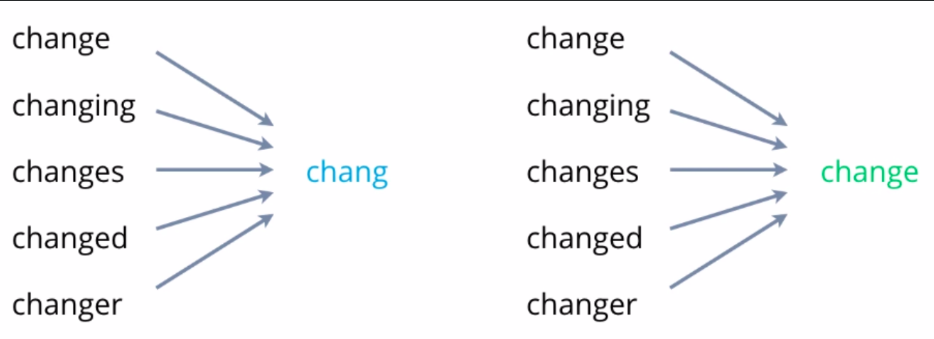

In [24]:
from nltk.stem import PorterStemmer

def stemming(text):
  """
  This function performs stemming operations.
  Input Args:
  token_text: list of tokenize text.
  Returns:
  stemm_tokes: list of stemmed tokens.
  """
  porter = PorterStemmer()
  stemm_tokens = []
  for word in text:
    stemm_tokens.append(porter.stem(word))
  return stemm_tokens

In [25]:
#Test
print("+++++++++++++++++++++++++++++++" "INPUT TOKENS" "++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
token_text_test=['Connects','Connecting','Connections','Connected','Connection','Connectings','Connect']
print(token_text_test)
print("++++++++++++++++++" "LEMMATIZED TOKENS" "+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
lemma_tokens = lemmatization(token_text_test)
print(lemma_tokens)
print("+++++++++++++++++++++" "STEMMED TOKENS" "+++++++++++++++++++++++++++++++++++++")
stemmed_tokens = stemming(token_text_test)
print(stemmed_tokens)


+++++++++++++++++++++++++++++++INPUT TOKENS++++++++++++++++++++++++++++++++++++++++++++++++++++++++
['Connects', 'Connecting', 'Connections', 'Connected', 'Connection', 'Connectings', 'Connect']
++++++++++++++++++LEMMATIZED TOKENS+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
['Connects', 'Connecting', 'Connections', 'Connected', 'Connection', 'Connectings', 'Connect']
+++++++++++++++++++++STEMMED TOKENS+++++++++++++++++++++++++++++++++++++
['connect', 'connect', 'connect', 'connect', 'connect', 'connect', 'connect']


Lower order

In [26]:
def lower_order(text):
  """
  This function converts all the text in input text to lower order.
  Input Args:
  token_text : input text.
  Returns:
  small_order_text : text converted to small/lower order.
  """
  small_order_text = text.lower()
  return small_order_text

# Test:
sample_text = "This Is some Normalized TEXT"
sample_small = lower_order(sample_text)
print(sample_small)


this is some normalized text


## Create Input Text Pipeline

We will compile every basic cleaning steps in following one functions and implement with our datasets.

### Exercise-1:
Read the provided data "trump_tweets.csv" and complete the followiing compilin function.


Reading data

In [27]:
data = pd.read_csv("/content/drive/MyDrive/trum_tweet_sentiment_analysis.csv", encoding="ISO-8859-1")

data.head()

,text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


In [28]:
data_cleaning = data["text"].dropna()

In [29]:
data_cleaning[0]

'RT @JohnLeguizamo: #trump not draining swamp but our taxpayer dollars on his trips to advertise his properties! @realDonaldTrumpÂ\x85 https://t.co/gFBvUkMX9z'

In [30]:
from nltk.stem import WordNetLemmatizer

def text_cleaning_pipeline(dataset, rule="lemmatize"):
    """
    Clean text data using preprocessing pipeline.
    Works for both single string and list of strings.
    """

    wordnet = WordNetLemmatizer()

    def process(text):
        # Lowercase
        text = lower_order(text)

        # Remove URLs
        text = remove_urls(text)

        # Remove emojis
        text = remove_emoji(text)

        # Remove unwanted characters
        text = removeunwanted_characters(text)

        # Tokenization
        tokens = text.split()

        # Remove stopwords
        tokens = [word for word in tokens if word not in stop_words]

        # Lemmatization only
        if rule == "lemmatize":
            tokens = [wordnet.lemmatize(word, pos='v') for word in tokens]
        elif rule == "none":
            pass
        else:
            raise ValueError("Choose 'lemmatize' or 'none'")

        return " ".join(tokens)

    # If input is a single string
    if isinstance(dataset, str):
        return process(dataset)

    # If input is a list of texts
    elif isinstance(dataset, list):
        return [process(text) for text in dataset]

    else:
        raise TypeError("Input must be a string or a list of strings")


Observation:

The text_cleaning_pipeline function is designed to preprocess raw text data in a structured way for NLP tasks. It takes either a single string or a list of strings as input and applies a series of cleaning steps, including converting text to lowercase, removing URLs, emojis, and unwanted characters, and splitting the text into tokens. It then removes stopwords to keep only meaningful words. Finally, based on the selected rule, it either applies lemmatization to convert words into their base form or leaves them unchanged. The function processes each text individually without using pandas, making it simple and flexible for different input types. Overall, it produces clean, normalized text that is suitable for further analysis or machine learning models.



In [31]:
texts = "Hello @gabe_flomo 👋🏾, I still want us to hit that new sushi spot??? LMK when you're free cuz I can't go this or next weekend since I'll be swimming!!! #sushiBros #rawFish #🍱"
print(text_cleaning_pipeline(texts))




hello still want us hit new sushi spot lmk youre free cuz cant go next weekend since ill swim


Observation:

In this step, a sample noisy text message containing usernames, emojis, hashtags, punctuation, and informal language is passed into the text_cleaning_pipeline function. The function processes the input by converting it to lowercase, removing URLs, emojis, unwanted characters, and stopwords, and then applies lemmatization to reduce words to their base forms. Since the input is a single string, the pipeline processes it directly without looping over a dataset. The final output is a cleaned and normalized version of the original message, where only meaningful words remain. This demonstrates how the pipeline effectively transforms unstructured social media text into a structured format suitable for NLP tasks such as sentiment analysis or text classification.


In [32]:
test = data["text"][0]

In [33]:
print(text_cleaning_pipeline(test))

rtnot drain swamp taxpayer dollars trip advertise properties


In [34]:
cleaned_tokens = data["text"].apply(lambda dataset: text_cleaning_pipeline(dataset))


In [35]:
cleaned_tokens[0]

'rtnot drain swamp taxpayer dollars trip advertise properties'